# Regressão Linear com Dados de Energia Solar

**Objetivo:** utilizar dados horários reais do **PVGIS** para estimar a potência produzida por um sistema fotovoltaico por meio de dois modelos de Regressão Linear.

### Localização escolhida
- **Cidade:** São Paulo - SP
- **Latitude:** -23.5505
- **Longitude:** -46.6333
- **Período analisado:** 2021
- **Fonte:** PVGIS (Photovoltaic Geographical Information System)
- **Recurso da API:** `seriescalc`

Ao longo do notebook serão feitas as etapas de obtenção dos dados, preparação, visualização, correlação, treinamento, avaliação e comparação dos modelos.

## 1. Importação das bibliotecas

Serão utilizadas bibliotecas para:
- realizar a requisição à API;
- organizar os dados em DataFrame;
- criar gráficos;
- separar treino e teste;
- treinar e avaliar os modelos de Regressão Linear.

In [1]:
# Bibliotecas para requisição e manipulação dos dados
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Requisição à API do PVGIS

A API será consultada usando o recurso `seriescalc`, responsável pelos dados horários.

Parâmetros principais:
- `lat` e `lon`: localização;
- `startyear` e `endyear`: período;
- `pvcalculation = 1`: solicita cálculo da potência fotovoltaica;
- `peakpower = 1`: sistema de 1 kWp;
- `loss = 14`: perdas estimadas de 14%;
- `optimalangles = 1`: utiliza orientação e inclinação otimizadas;
- `outputformat = json`: retorno em formato JSON.

In [2]:
# Endereço do recurso de dados horários do PVGIS
url = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"

# Parâmetros da consulta
parametros = {
    "lat": -23.5505,
    "lon": -46.6333,
    "startyear": 2021,
    "endyear": 2021,
    "pvcalculation": 1,
    "peakpower": 1,
    "loss": 14,
    "optimalangles": 1,
    "outputformat": "json"
}

# Realiza a requisição
resposta = requests.get(url, params=parametros)

print("=" * 60)
print("RESULTADO DA REQUISIÇÃO")
print("=" * 60)
print(f"Status HTTP: {resposta.status_code}")
print(f"Endereço utilizado:\n{resposta.url}")

if resposta.status_code == 200:
    print("\n✓ Requisição realizada com sucesso!")
else:
    print("\n✗ Houve um problema na requisição.")

RESULTADO DA REQUISIÇÃO
Status HTTP: 200
Endereço utilizado:
https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat=-23.5505&lon=-46.6333&startyear=2021&endyear=2021&pvcalculation=1&peakpower=1&loss=14&optimalangles=1&outputformat=json

✓ Requisição realizada com sucesso!


## 3. Verificação da estrutura da resposta

Antes de criar o DataFrame, verificamos como os dados recebidos estão organizados.

In [3]:
# Converte a resposta JSON em um dicionário Python
dados = resposta.json()

print("Chaves principais retornadas pela API:")
print(list(dados.keys()))

print("\nConteúdos disponíveis dentro de 'outputs':")
print(list(dados["outputs"].keys()))

Chaves principais retornadas pela API:
['inputs', 'outputs', 'meta']

Conteúdos disponíveis dentro de 'outputs':
['hourly']


## 4. Criação do DataFrame

Os registros horários ficam em `outputs → hourly`.  
Eles serão transformados em um DataFrame chamado `df`, conforme solicitado no exercício.

In [4]:
# Cria o DataFrame a partir dos registros horários
df = pd.DataFrame(dados["outputs"]["hourly"])

print("=" * 60)
print("DATAFRAME CRIADO")
print("=" * 60)
print(f"Quantidade inicial de linhas: {df.shape[0]}")
print(f"Quantidade inicial de colunas: {df.shape[1]}")

print("\nPrimeiras 5 linhas:")
display(df.head())

DATAFRAME CRIADO
Quantidade inicial de linhas: 8760
Quantidade inicial de colunas: 7

Primeiras 5 linhas:


,time,P,G(i),H_sun,T2m,WS10m,Int
0,20210101:0003,0.0,0.0,0.0,21.48,2.76,0.0
1,20210101:0103,0.0,0.0,0.0,20.87,2.48,0.0
2,20210101:0203,0.0,0.0,0.0,20.59,2.00,0.0
3,20210101:0303,0.0,0.0,0.0,20.44,1.72,0.0
4,20210101:0403,0.0,0.0,0.0,20.26,1.86,0.0


## 5. Seleção das variáveis importantes

Primeiro são conferidos os nomes das colunas retornadas pela API.  
Depois, mantemos apenas as variáveis necessárias para a atividade:

- `time`: data e horário;
- `P`: potência fotovoltaica;
- `G(i)`: irradiância;
- `H_sun`: altura do Sol;
- `T2m`: temperatura;
- `WS10m`: velocidade do vento.

In [5]:
print("Colunas retornadas pela API:")
print(df.columns.tolist())

Colunas retornadas pela API:
['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m', 'Int']


In [6]:
# Mantém apenas as colunas necessárias para a análise
colunas_utilizadas = ["time", "P", "G(i)", "H_sun", "T2m", "WS10m"]

# Verifica se todas elas existem antes da seleção
colunas_encontradas = [coluna for coluna in colunas_utilizadas if coluna in df.columns]

df = df[colunas_encontradas].copy()

print("Colunas mantidas no DataFrame:")
print(df.columns.tolist())

display(df.head())

Colunas mantidas no DataFrame:
['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m']


,time,P,G(i),H_sun,T2m,WS10m
0,20210101:0003,0.0,0.0,0.0,21.48,2.76
1,20210101:0103,0.0,0.0,0.0,20.87,2.48
2,20210101:0203,0.0,0.0,0.0,20.59,2.00
3,20210101:0303,0.0,0.0,0.0,20.44,1.72
4,20210101:0403,0.0,0.0,0.0,20.26,1.86


## 6. Inspeção inicial do DataFrame

Nesta etapa são verificadas:
- dimensões;
- nomes das colunas;
- tipos de dados;
- valores ausentes;
- estatísticas descritivas.

In [7]:
print("=" * 60)
print("RESUMO DO DATAFRAME")
print("=" * 60)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\nNomes das colunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

RESUMO DO DATAFRAME
Linhas: 8760
Colunas: 6

Nomes das colunas:
['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m']

Tipos de dados:
time      object
P        float64
G(i)     float64
H_sun    float64
T2m      float64
WS10m    float64
dtype: object

Valores ausentes por coluna:
time     0
P        0
G(i)     0
H_sun    0
T2m      0
WS10m    0
dtype: int64


In [8]:
print("=" * 60)
print("ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS")
print("=" * 60)

display(df.describe())

ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS


,P,G(i),H_sun,T2m,WS10m
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,161.374463,211.989742,18.667857,19.248856,2.191424
std,243.135830,317.201358,24.326960,4.511217,1.118499
min,0.000000,0.000000,0.000000,2.070000,0.000000
25%,0.000000,0.000000,0.000000,16.030000,1.380000
50%,0.000000,0.000000,0.000000,19.180000,2.000000
75%,292.195000,375.195000,36.820000,22.180000,2.900000
max,849.630000,1129.560000,89.840000,33.310000,7.520000


## 7. Análise dos períodos sem geração

Durante a noite, a irradiância solar é igual ou próxima de zero e, consequentemente, a produção fotovoltaica também tende a ser zero.

Para o treinamento, serão utilizados apenas os registros com **irradiância maior que zero**. Isso evita que uma grande quantidade de registros noturnos com potência zero domine o conjunto de dados e influencie artificialmente as métricas.

In [9]:
# Conta registros sem irradiância
sem_irradiancia = (df["G(i)"] <= 0).sum()

print("=" * 60)
print("REGISTROS SEM IRRADIÂNCIA")
print("=" * 60)
print(f"Registros com G(i) <= 0: {sem_irradiancia}")
print(f"Total de registros: {len(df)}")

# Mantém apenas períodos com irradiância positiva
df_modelo = df[df["G(i)"] > 0].copy()

print(f"\nRegistros utilizados no modelo: {len(df_modelo)}")
print(f"Registros removidos: {len(df) - len(df_modelo)}")

REGISTROS SEM IRRADIÂNCIA
Registros com G(i) <= 0: 4455
Total de registros: 8760

Registros utilizados no modelo: 4305
Registros removidos: 4455


## 8. Visualização das relações entre as variáveis

Os gráficos de dispersão ajudam a observar visualmente como algumas variáveis se relacionam com a potência fotovoltaica `P`.

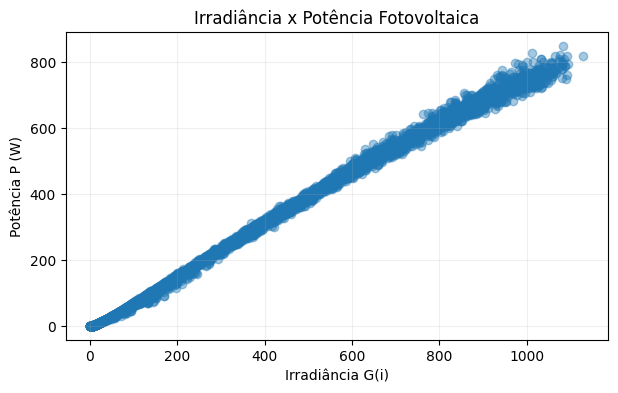

In [10]:
# Gráfico 1: irradiância x potência
plt.figure(figsize=(7, 4))
plt.scatter(df_modelo["G(i)"], df_modelo["P"], alpha=0.4)
plt.xlabel("Irradiância G(i)")
plt.ylabel("Potência P (W)")
plt.title("Irradiância x Potência Fotovoltaica")
plt.grid(alpha=0.2)
plt.show()

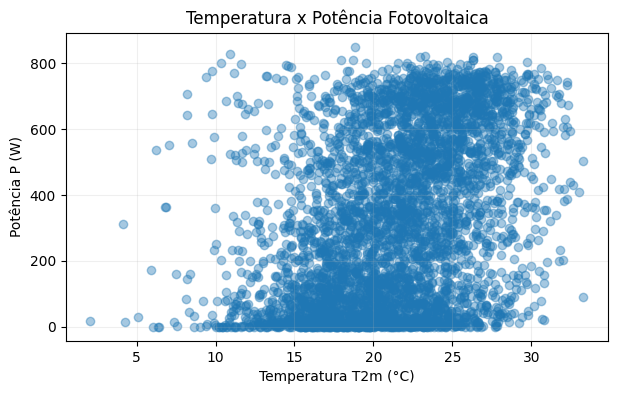

In [11]:
# Gráfico 2: temperatura x potência
plt.figure(figsize=(7, 4))
plt.scatter(df_modelo["T2m"], df_modelo["P"], alpha=0.4)
plt.xlabel("Temperatura T2m (°C)")
plt.ylabel("Potência P (W)")
plt.title("Temperatura x Potência Fotovoltaica")
plt.grid(alpha=0.2)
plt.show()

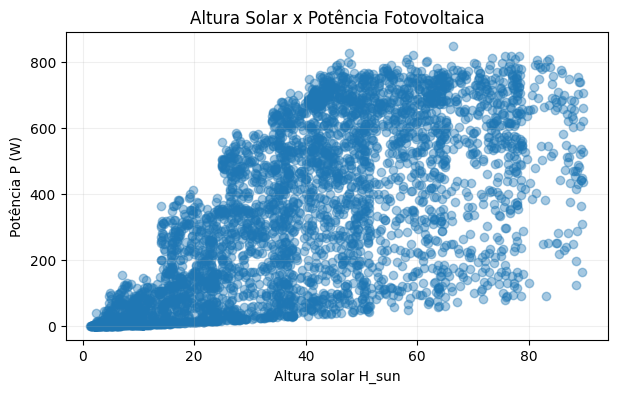

In [12]:
# Gráfico 3: altura solar x potência
plt.figure(figsize=(7, 4))
plt.scatter(df_modelo["H_sun"], df_modelo["P"], alpha=0.4)
plt.xlabel("Altura solar H_sun")
plt.ylabel("Potência P (W)")
plt.title("Altura Solar x Potência Fotovoltaica")
plt.grid(alpha=0.2)
plt.show()

## 9. Matriz de correlação

A correlação varia de **-1 a 1**:

- próxima de **1**: relação linear positiva forte;
- próxima de **-1**: relação linear negativa forte;
- próxima de **0**: relação linear fraca.

O principal interesse é observar a correlação das variáveis com a potência `P`.

In [13]:
# Seleciona apenas variáveis numéricas usadas na análise
variaveis_numericas = ["P", "G(i)", "H_sun", "T2m", "WS10m"]

correlacao = df_modelo[variaveis_numericas].corr()

print("=" * 60)
print("MATRIZ DE CORRELAÇÃO")
print("=" * 60)
display(correlacao.round(3))

# Mostra as correlações com a potência em ordem
corr_potencia = correlacao["P"].drop("P").sort_values(ascending=False)

print("\nCorrelação de cada variável com a potência P:")
display(corr_potencia.round(3))

MATRIZ DE CORRELAÇÃO


,P,G(i),H_sun,T2m,WS10m
P,1.000,0.998,0.680,0.379,0.009
G(i),0.998,1.000,0.685,0.405,-0.010
H_sun,0.680,0.685,1.000,0.471,0.164
T2m,0.379,0.405,0.471,1.000,0.004
WS10m,0.009,-0.010,0.164,0.004,1.000



Correlação de cada variável com a potência P:


,P
G(i),0.998
H_sun,0.680
T2m,0.379
WS10m,0.009


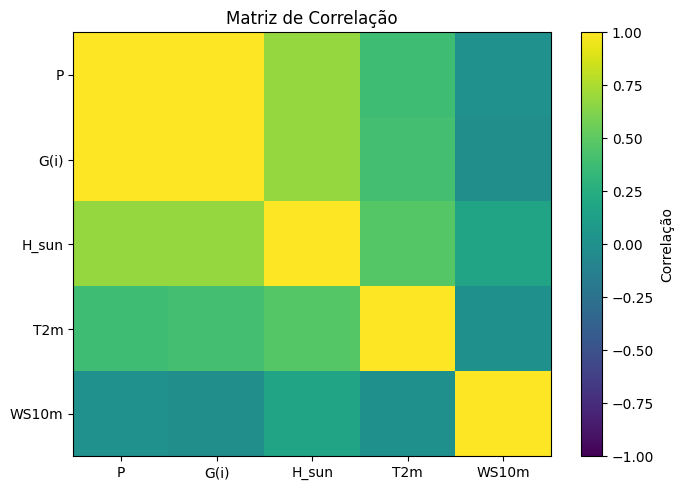

In [14]:
# Visualização simples da matriz de correlação
plt.figure(figsize=(7, 5))
plt.imshow(correlacao, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlação")

plt.xticks(range(len(correlacao.columns)), correlacao.columns)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

## 10. Definição da variável alvo e dos dois modelos

A variável alvo será:

- **y = `P`**, potência fotovoltaica.

Serão comparadas duas combinações de entradas:

### Modelo 1
Utiliza duas variáveis diretamente relacionadas à disponibilidade de energia solar:
- `G(i)` — irradiância;
- `H_sun` — altura solar.

### Modelo 2
Adiciona condições meteorológicas ao primeiro conjunto:
- `G(i)`;
- `H_sun`;
- `T2m`;
- `WS10m`.

Assim, podemos verificar se adicionar temperatura e vento melhora a previsão.

In [15]:
# Variável alvo
y = df_modelo["P"]

# Entradas do Modelo 1
X1 = df_modelo[["G(i)", "H_sun"]]

# Entradas do Modelo 2
X2 = df_modelo[["G(i)", "H_sun", "T2m", "WS10m"]]

print("Variável alvo (y): P")
print("Modelo 1:", X1.columns.tolist())
print("Modelo 2:", X2.columns.tolist())

Variável alvo (y): P
Modelo 1: ['G(i)', 'H_sun']
Modelo 2: ['G(i)', 'H_sun', 'T2m', 'WS10m']


## 11. Separação entre treino e teste

Serão reservados **20% dos dados para teste** e **80% para treinamento**.

O mesmo `random_state = 42` será utilizado nos dois modelos para tornar a comparação reproduzível.

In [16]:
# Separação do Modelo 1
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y,
    test_size=0.20,
    random_state=42
)

# Separação do Modelo 2
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("DIMENSÕES DOS CONJUNTOS")
print("=" * 60)

print("Modelo 1")
print(f"Treino: {X_train1.shape}")
print(f"Teste:  {X_test1.shape}")

print("\nModelo 2")
print(f"Treino: {X_train2.shape}")
print(f"Teste:  {X_test2.shape}")

DIMENSÕES DOS CONJUNTOS
Modelo 1
Treino: (3444, 2)
Teste:  (861, 2)

Modelo 2
Treino: (3444, 4)
Teste:  (861, 4)


## 12. Treinamento e avaliação do Modelo 1

O primeiro modelo será armazenado na variável `modeloLR1`.

In [17]:
# Cria e treina o Modelo 1
modeloLR1 = LinearRegression()
modeloLR1.fit(X_train1, y_train1)

# Faz as previsões
y_pred1 = modeloLR1.predict(X_test1)

# Calcula as métricas
mae1 = mean_absolute_error(y_test1, y_pred1)
mse1 = mean_squared_error(y_test1, y_pred1)
r2_1 = r2_score(y_test1, y_pred1)

print("=" * 60)
print("RESULTADOS DO MODELO 1")
print("=" * 60)
print(f"MAE: {mae1:.2f}")
print(f"MSE: {mse1:.2f}")
print(f"R²:  {r2_1:.4f}")

RESULTADOS DO MODELO 1
MAE: 10.54
MSE: 217.08
R²:  0.9967


## 13. Treinamento e avaliação do Modelo 2

O segundo modelo será armazenado na variável `modeloLR2`.

In [18]:
# Cria e treina o Modelo 2
modeloLR2 = LinearRegression()
modeloLR2.fit(X_train2, y_train2)

# Faz as previsões
y_pred2 = modeloLR2.predict(X_test2)

# Calcula as métricas
mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("=" * 60)
print("RESULTADOS DO MODELO 2")
print("=" * 60)
print(f"MAE: {mae2:.2f}")
print(f"MSE: {mse2:.2f}")
print(f"R²:  {r2_2:.4f}")

RESULTADOS DO MODELO 2
MAE: 9.29
MSE: 139.86
R²:  0.9978


## 14. Comparação dos modelos

Para a avaliação:

- **MAE:** quanto menor, melhor;
- **MSE:** quanto menor, melhor;
- **R²:** quanto maior e mais próximo de 1, melhor.

In [19]:
comparacao = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [
        "G(i), H_sun",
        "G(i), H_sun, T2m, WS10m"
    ],
    "MAE": [mae1, mae2],
    "MSE": [mse1, mse2],
    "R²": [r2_1, r2_2]
})

print("=" * 60)
print("COMPARAÇÃO FINAL")
print("=" * 60)

display(comparacao.round({
    "MAE": 2,
    "MSE": 2,
    "R²": 4
}))

COMPARAÇÃO FINAL


,Modelo,Variáveis utilizadas,MAE,MSE,R²
0,Modelo 1,"G(i), H_sun",10.54,217.08,0.9967
1,Modelo 2,"G(i), H_sun, T2m, WS10m",9.29,139.86,0.9978


# 15. Análise final

As quatro primeiras respostas abaixo são determinadas automaticamente a partir das métricas obtidas, evitando conclusões sem base nos resultados reais.

In [20]:
# Identifica automaticamente o melhor resultado em cada métrica
melhor_r2 = "Modelo 1" if r2_1 > r2_2 else "Modelo 2"
melhor_mae = "Modelo 1" if mae1 < mae2 else "Modelo 2"
melhor_mse = "Modelo 1" if mse1 < mse2 else "Modelo 2"

mesmo_modelo = melhor_r2 == melhor_mae == melhor_mse

print("=" * 70)
print("RESPOSTAS DAS QUESTÕES FINAIS")
print("=" * 70)

print(f"1. Qual dos dois modelos apresentou maior R²?")
print(f"   {melhor_r2}, com o maior valor de R².\n")

print("2. Qual apresentou menor MAE?")
print(f"   {melhor_mae}, pois apresentou o menor erro absoluto médio.\n")

print("3. Qual apresentou menor MSE?")
print(f"   {melhor_mse}, pois apresentou o menor erro quadrático médio.\n")

print("4. As três métricas apontam para o mesmo modelo como melhor opção?")
if mesmo_modelo:
    print(f"   Sim. R², MAE e MSE indicam o {melhor_r2} como a melhor opção.\n")
else:
    print("   Não. As métricas não apontaram todas para o mesmo modelo, por isso a escolha")
    print("   deve considerar o conjunto dos resultados e o objetivo da análise.\n")

print("5. As variáveis com maior correlação foram necessariamente as que produziram o melhor modelo?")
print("   Não necessariamente. A correlação analisa a relação de cada variável isoladamente com")
print("   a potência, enquanto o modelo considera a combinação das variáveis. Uma variável pode")
print("   ter correlação menor e ainda contribuir para melhorar a previsão quando usada com outras.\n")

print("6. Os gráficos de dispersão indicam relações aproximadamente lineares?")
print("   A irradiância tende a apresentar a relação linear mais evidente com a potência.")
print("   Já temperatura, vento e altura solar podem apresentar maior dispersão. Portanto,")
print("   algumas relações são aproximadamente lineares, mas não todas com a mesma intensidade.\n")

print("7. Que fatores podem dificultar a previsão da potência fotovoltaica por meio de um modelo linear?")
print("   Variações de nuvens, temperatura, vento, posição do Sol, sombras e mudanças rápidas")
print("   na irradiância podem criar relações que não são perfeitamente lineares. Além disso,")
print("   um modelo linear possui dificuldade para representar interações mais complexas entre")
print("   as condições meteorológicas e a geração fotovoltaica.")

RESPOSTAS DAS QUESTÕES FINAIS
1. Qual dos dois modelos apresentou maior R²?
   Modelo 2, com o maior valor de R².

2. Qual apresentou menor MAE?
   Modelo 2, pois apresentou o menor erro absoluto médio.

3. Qual apresentou menor MSE?
   Modelo 2, pois apresentou o menor erro quadrático médio.

4. As três métricas apontam para o mesmo modelo como melhor opção?
   Sim. R², MAE e MSE indicam o Modelo 2 como a melhor opção.

5. As variáveis com maior correlação foram necessariamente as que produziram o melhor modelo?
   Não necessariamente. A correlação analisa a relação de cada variável isoladamente com
   a potência, enquanto o modelo considera a combinação das variáveis. Uma variável pode
   ter correlação menor e ainda contribuir para melhorar a previsão quando usada com outras.

6. Os gráficos de dispersão indicam relações aproximadamente lineares?
   A irradiância tende a apresentar a relação linear mais evidente com a potência.
   Já temperatura, vento e altura solar podem apresenta

## Conclusão

Os dois modelos utilizam Regressão Linear para estimar a potência fotovoltaica. A comparação por **MAE, MSE e R²** permite verificar se a inclusão de mais variáveis meteorológicas trouxe ganho de desempenho.

A decisão sobre o melhor modelo deve ser feita com base nas métricas calculadas e na coerência das relações observadas nos gráficos e na matriz de correlação.